<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Visualization**


Estimated time needed: **45** minutes


In this lab, you will focus on data visualization. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


After completing this lab, you will be able to:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition and comparison of data.




## Demo: How to work with database


Download the database file.


In [3]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

'wget' is not recognized as an internal or external command,
operable program or batch file.


**Install and Import Necessary Python Libraries**

Ensure that you have the required libraries installed to work with SQLite and Pandas:


In [4]:
!pip install pandas 
!pip install matplotlib
!pip install seaborn
import pandas as pd
import matplotlib.pyplot as plt

**Read the CSV File into a Pandas DataFrame**

Load the Stack Overflow survey data into a Pandas DataFrame:


In [5]:
# Read the CSV file
df = pd.read_csv('survey-data.csv')

# Display the first few rows of the data
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


**Create a SQLite Database and Insert the Data**

Now, let's create a new SQLite database (`survey-data.sqlite`) and insert the data from the DataFrame into a table using the sqlite3 library:


In [6]:
import sqlite3

# Create a connection to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Write the dataframe to the SQLite database
df.to_sql('main', conn, if_exists='replace', index=False)


# Close the connection
conn.close()


**Verify the Data in the SQLite Database**
Verify that the data has been correctly inserted into the SQLite database by running a simple query:


In [7]:
# Reconnect to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Run a simple query to check the data
QUERY = "SELECT * FROM main LIMIT 5"
df_check = pd.read_sql_query(QUERY, conn)

# Display the results
print(df_check)


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time       None  Apples   
4   Student, full-time       None  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                               None   
4                                 

## Demo: Running an SQL Query


Count the number of rows in the table named 'main'


In [8]:
QUERY = """
SELECT COUNT(*) as total_rows
FROM main
"""
df = pd.read_sql_query(QUERY, conn)
df.head()


,total_rows
0,65437


## Demo: Listing All Tables


To view the names of all tables in the database:


In [9]:
QUERY = """
SELECT name as Table_Name FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


## Demo: Running a Group By Query
    
For example, you can group data by a specific column, like Age, to get the count of respondents in each age group:


In [10]:
QUERY = """
SELECT Age, COUNT(*) as count
FROM main
GROUP BY Age
ORDER BY Age
"""
pd.read_sql_query(QUERY, conn)


,Age,count
0,18-24 years old,14098
1,25-34 years old,23911
2,35-44 years old,14942
3,45-54 years old,6249
4,55-64 years old,2575
5,65 years or older,772
6,Prefer not to say,322
7,Under 18 years old,2568


## Demo: Describing a table

Use this query to get the schema of a specific table, main in this case:


In [11]:
table_name = 'main'

QUERY = """
SELECT sql FROM sqlite_master 
WHERE name= '{}'
""".format(table_name)

df = pd.read_sql_query(QUERY, conn)
print(df.iat[0,0])


CREATE TABLE "main" (
"ResponseId" INTEGER,
  "MainBranch" TEXT,
  "Age" TEXT,
  "Employment" TEXT,
  "RemoteWork" TEXT,
  "Check" TEXT,
  "CodingActivities" TEXT,
  "EdLevel" TEXT,
  "LearnCode" TEXT,
  "LearnCodeOnline" TEXT,
  "TechDoc" TEXT,
  "YearsCode" TEXT,
  "YearsCodePro" TEXT,
  "DevType" TEXT,
  "OrgSize" TEXT,
  "PurchaseInfluence" TEXT,
  "BuyNewTool" TEXT,
  "BuildvsBuy" TEXT,
  "TechEndorse" TEXT,
  "Country" TEXT,
  "Currency" TEXT,
  "CompTotal" REAL,
  "LanguageHaveWorkedWith" TEXT,
  "LanguageWantToWorkWith" TEXT,
  "LanguageAdmired" TEXT,
  "DatabaseHaveWorkedWith" TEXT,
  "DatabaseWantToWorkWith" TEXT,
  "DatabaseAdmired" TEXT,
  "PlatformHaveWorkedWith" TEXT,
  "PlatformWantToWorkWith" TEXT,
  "PlatformAdmired" TEXT,
  "WebframeHaveWorkedWith" TEXT,
  "WebframeWantToWorkWith" TEXT,
  "WebframeAdmired" TEXT,
  "EmbeddedHaveWorkedWith" TEXT,
  "EmbeddedWantToWorkWith" TEXT,
  "EmbeddedAdmired" TEXT,
  "MiscTechHaveWorkedWith" TEXT,
  "MiscTechWantToWorkWith" TEXT,


## Hands-on Lab


### Visualizing the Distribution of Data

**Histograms**

Plot a histogram of CompTotal (Total Compensation).


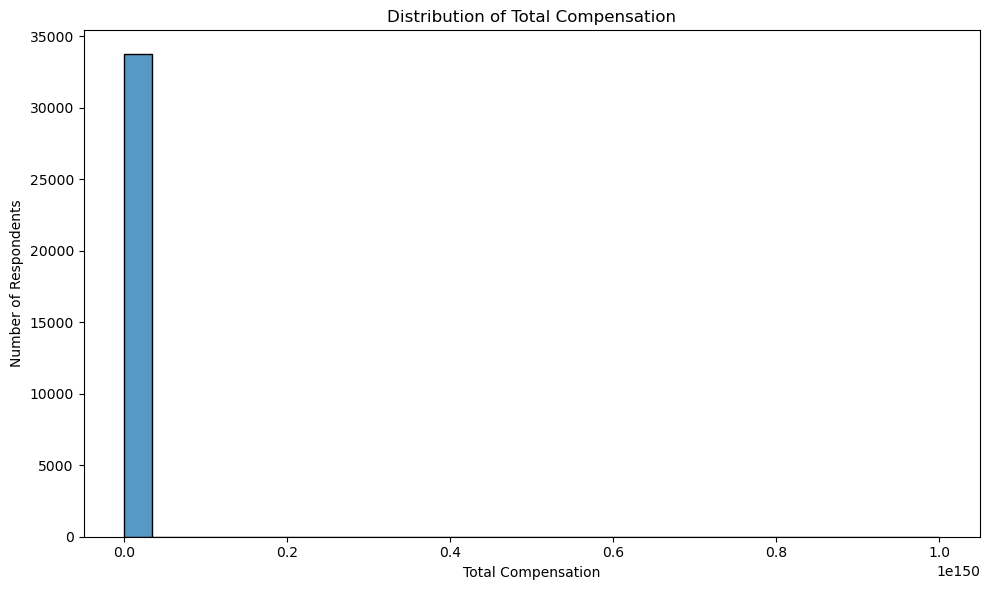

In [13]:
## Write your code here
import seaborn as sns
QUERY = """SELECT CompTotal FROM main WHERE CompTotal IS NOT NULL"""

comp_df = pd.read_sql_query(QUERY, conn)

plt.figure(figsize=(10, 6))

sns.histplot(
    data=comp_df,
    x="CompTotal",
    bins=30,
    kde=False
)

plt.title("Distribution of Total Compensation")
plt.xlabel("Total Compensation")
plt.ylabel("Number of Respondents")

plt.tight_layout()
plt.show()

**Box Plots**

Plot a box plot of Age.


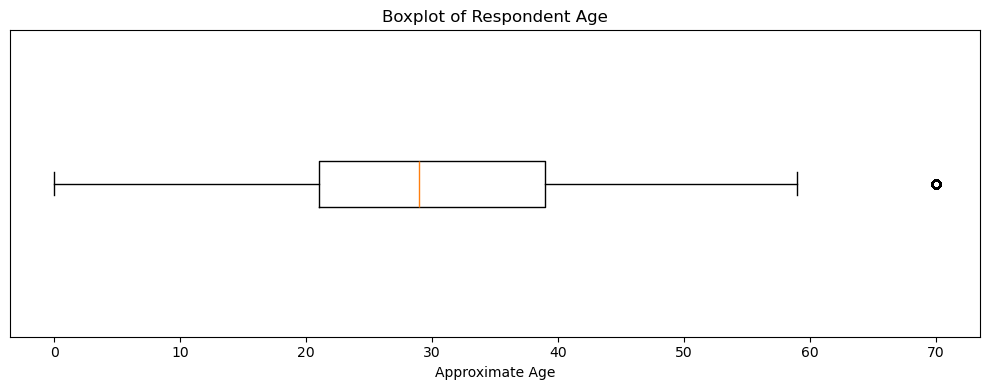

In [14]:
## Write your code here
QUERY = """SELECT Age FROM main
WHERE Age IS NOT NULL
"""
age_df = pd.read_sql_query(QUERY, conn)

age_mapping = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29,
    "35-44 years old": 39,
    "45-54 years old": 49,
    "55-64 years old": 59,
    "65 years or older": 70
}

age_df["AgeNumeric"] = age_df["Age"].map(age_mapping)
age_df["AgeNumeric"] = age_df["AgeNumeric"].fillna(0)


plt.figure(figsize=(10, 4))

plt.boxplot(
    age_df["AgeNumeric"],
    orientation="horizontal"
)

plt.title("Boxplot of Respondent Age")
plt.xlabel("Approximate Age")
plt.yticks([])

plt.tight_layout()
plt.show()

### Visualizing Relationships in Data

**Scatter Plots**

Create a scatter plot of Age and WorkExp.


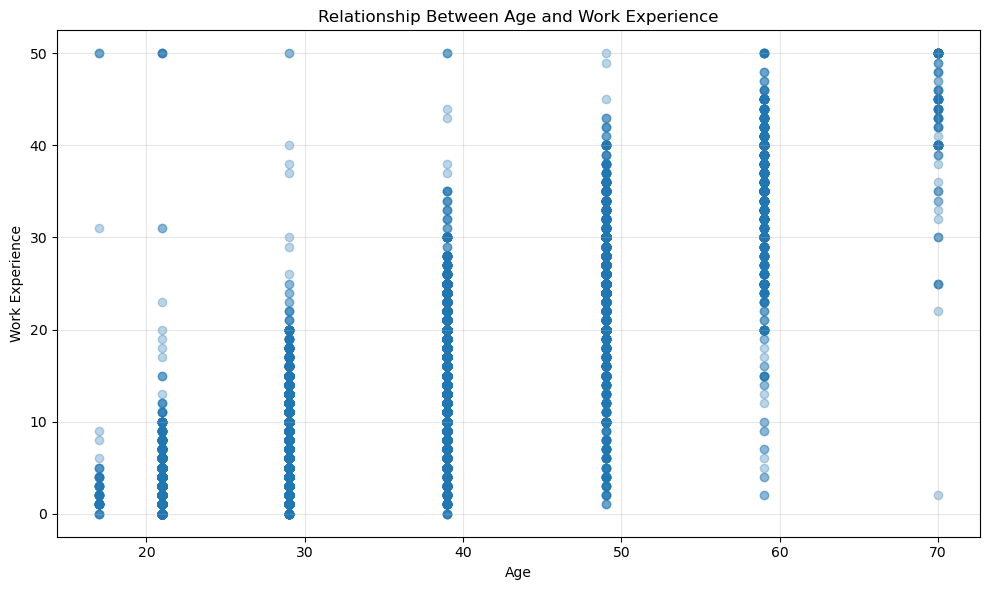

In [15]:
## Write your code here

QUERY = """
SELECT Age, WorkExp
FROM main
"""

age_work_df = pd.read_sql_query(QUERY, conn)

age_mapping = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29,
    "35-44 years old": 39,
    "45-54 years old": 49,
    "55-64 years old": 59,
    "65 years or older": 70
}

age_work_df["AgeNumeric"] = age_work_df["Age"].map(age_mapping)

plt.figure(figsize=(10, 6))

plt.scatter(
    age_work_df["AgeNumeric"],
    age_work_df["WorkExp"],
    alpha=0.3
)

plt.title("Relationship Between Age and Work Experience")
plt.xlabel("Age")
plt.ylabel("Work Experience")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Bubble Plots**

Create a bubble plot of `TimeSearching` and `Frustration` using the Age column as the bubble size.


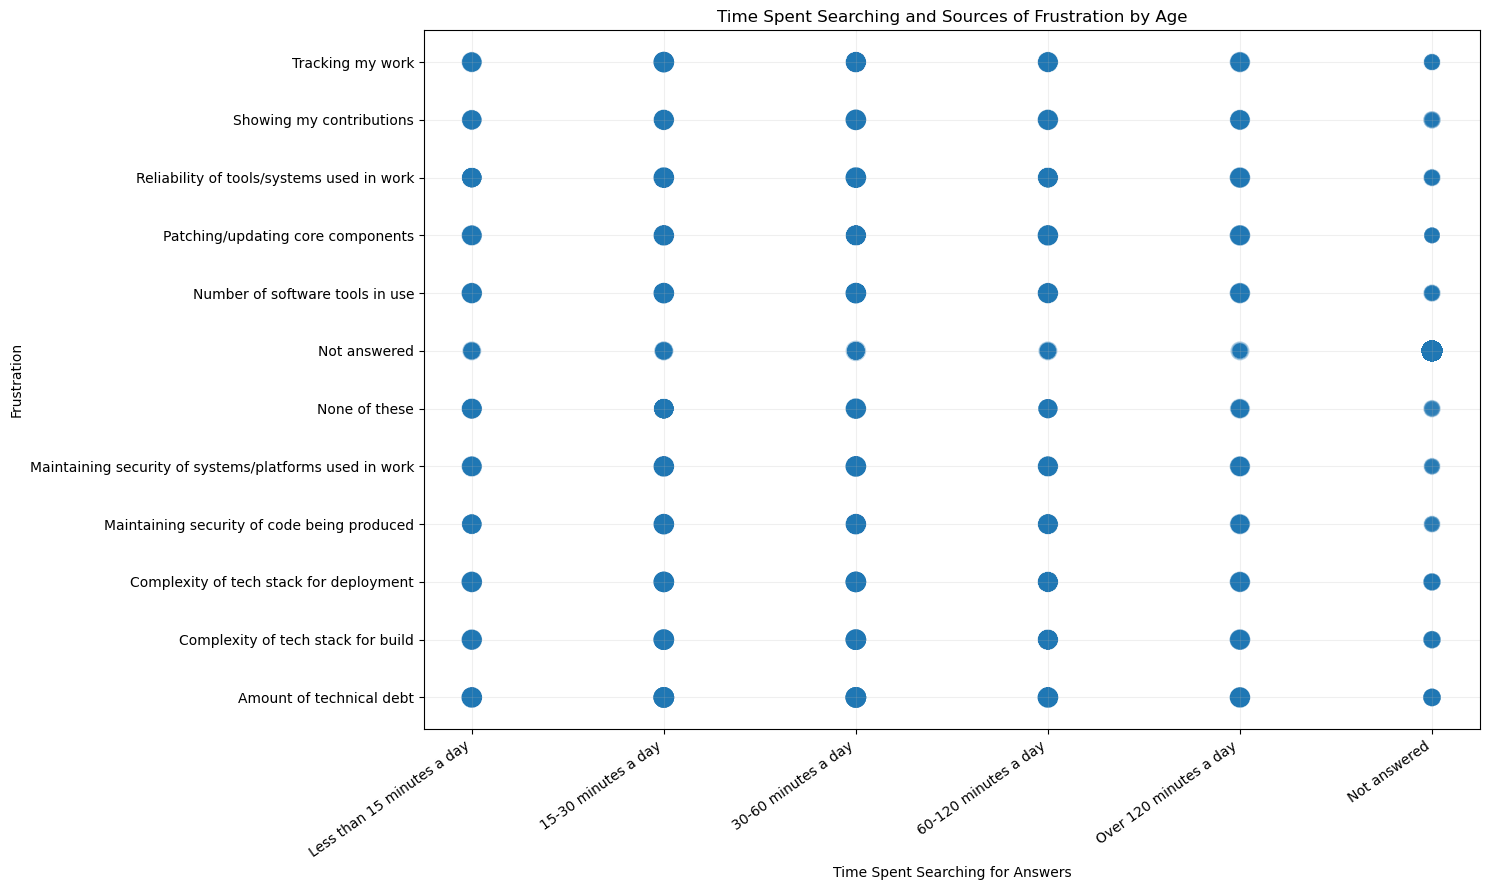

In [16]:
## Write your code here
QUERY = """
SELECT TimeSearching, Frustration, Age
FROM main
"""
bubble_df = pd.read_sql_query(QUERY, conn)

# Keep missing responses as categories
bubble_df["TimeSearching"] = bubble_df["TimeSearching"].fillna("Not answered")
bubble_df["Frustration"] = bubble_df["Frustration"].fillna("Not answered")
bubble_df["Age"] = bubble_df["Age"].fillna("Not answered")

# Separate multiple frustration responses
bubble_df["Frustration"] = bubble_df["Frustration"].str.split(";")
bubble_df = bubble_df.explode("Frustration")

# Remove extra spaces
bubble_df["Frustration"] = bubble_df["Frustration"].str.strip()

age_size_mapping = {
    "Under 18 years old": 40,
    "18-24 years old": 70,
    "25-34 years old": 100,
    "35-44 years old": 130,
    "45-54 years old": 160,
    "55-64 years old": 190,
    "65 years or older": 220,
    "Prefer not to say": 30,
    "Not answered": 20
}

bubble_df["BubbleSize"] = (
    bubble_df["Age"]
    .map(age_size_mapping)
    .fillna(20)
)

time_order = [
    "Less than 15 minutes a day",
    "15-30 minutes a day",
    "30-60 minutes a day",
    "60-120 minutes a day",
    "Over 120 minutes a day",
    "Not answered"
]

time_mapping = {
    value: position
    for position, value in enumerate(time_order)
}

frustration_categories = sorted(
    bubble_df["Frustration"].unique()
)

frustration_mapping = {
    value: position
    for position, value in enumerate(frustration_categories)
}

bubble_df["TimePosition"] = (
    bubble_df["TimeSearching"]
    .map(time_mapping)
)

bubble_df["FrustrationPosition"] = (
    bubble_df["Frustration"]
    .map(frustration_mapping)
)

plt.figure(figsize=(15, 9))

plt.scatter(
    bubble_df["TimePosition"],
    bubble_df["FrustrationPosition"],
    s=bubble_df["BubbleSize"],
    alpha=0.15,
    edgecolors="none"
)

plt.xticks(
    ticks=range(len(time_order)),
    labels=time_order,
    rotation=35,
    ha="right"
)

plt.yticks(
    ticks=range(len(frustration_categories)),
    labels=frustration_categories
)

plt.title("Time Spent Searching and Sources of Frustration by Age")
plt.xlabel("Time Spent Searching for Answers")
plt.ylabel("Frustration")
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### Visualizing Composition of Data

**Pie Charts**

Create a pie chart of the top 5 databases(`DatabaseWantToWorkWith`) that respondents wish to learn next year.


DatabaseWantToWorkWith
PostgreSQL    24005
SQLite        13489
MySQL         12269
MongoDB       10982
Redis         10847
Name: count, dtype: int64


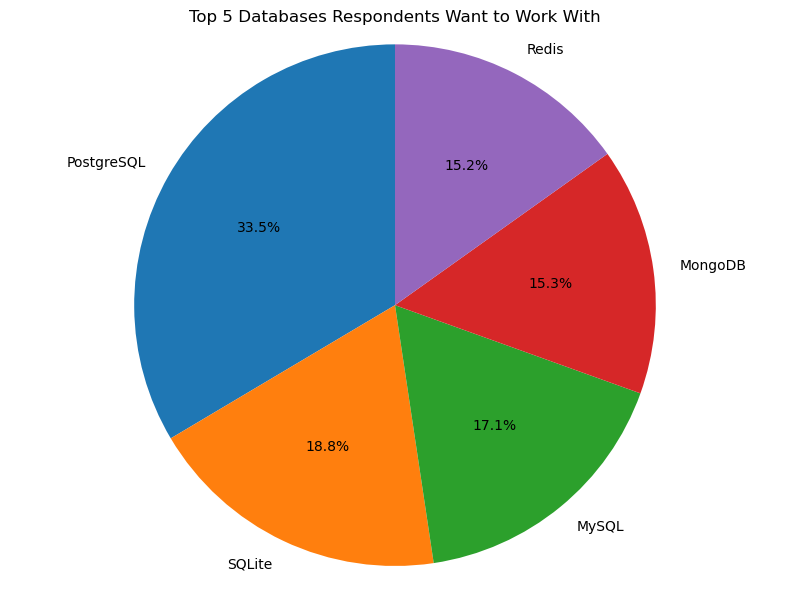

In [18]:
## Write your code here

QUERY = """
SELECT DatabaseWantToWorkWith
FROM main
WHERE DatabaseWantToWorkWith IS NOT NULL
"""

database_df = pd.read_sql_query(QUERY, conn)

# Split multiple database selections into separate values
databases = (
    database_df["DatabaseWantToWorkWith"]
    .str.split(";")
    .explode()
    .str.strip()
)

# Find the top 5 databases
top_5_databases = databases.value_counts().head(5)

print(top_5_databases)

plt.figure(figsize=(8, 6))

plt.pie(
    top_5_databases.values,
    labels=top_5_databases.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Top 5 Databases Respondents Want to Work With")
plt.axis("equal")

plt.tight_layout()
plt.show()

**Stacked Charts** 

Create a stacked bar chart of median `TimeSearching` and `TimeAnswering` for the age group 30 to 35.


Median time searching: 45.0
Median time answering: 22.5


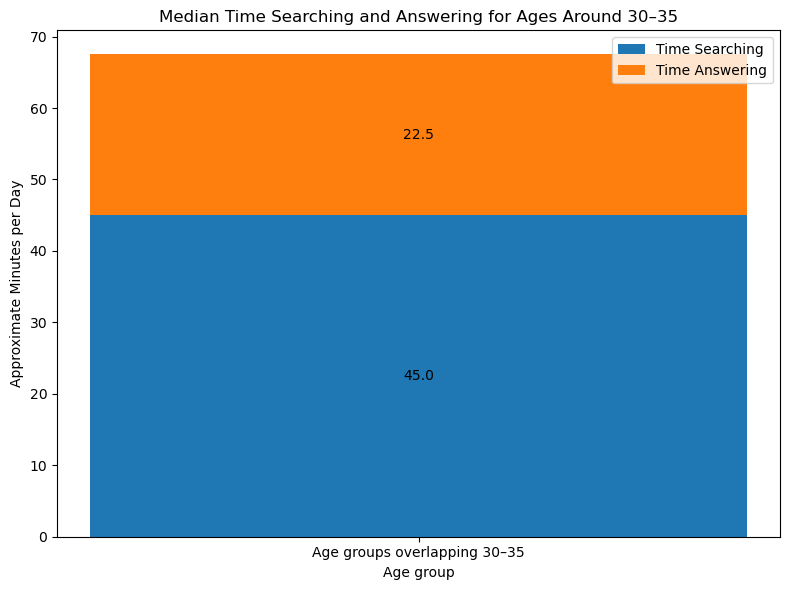

In [19]:
## Write your code here
QUERY = """
SELECT Age, TimeSearching, TimeAnswering
FROM main
WHERE Age IN (
    '25-34 years old',
    '35-44 years old'
)
"""

time_df = pd.read_sql_query(QUERY, conn)

time_mapping = {
    "Less than 15 minutes a day": 7.5,
    "15-30 minutes a day": 22.5,
    "30-60 minutes a day": 45,
    "60-120 minutes a day": 90,
    "Over 120 minutes a day": 150
}

time_df["SearchingMinutes"] = (
    time_df["TimeSearching"].map(time_mapping)
)

time_df["AnsweringMinutes"] = (
    time_df["TimeAnswering"].map(time_mapping)
)

median_searching = time_df["SearchingMinutes"].median()
median_answering = time_df["AnsweringMinutes"].median()

print("Median time searching:", median_searching)
print("Median time answering:", median_answering)

plt.figure(figsize=(8, 6))

plt.bar(
    ["Age groups overlapping 30–35"],
    [median_searching],
    label="Time Searching"
)

plt.bar(
    ["Age groups overlapping 30–35"],
    [median_answering],
    bottom=[median_searching],
    label="Time Answering"
)

plt.text(
    0,
    median_searching / 2,
    f"{median_searching:.1f}",
    ha="center",
    va="center"
)

plt.text(
    0,
    median_searching + median_answering / 2,
    f"{median_answering:.1f}",
    ha="center",
    va="center"
)

plt.title("Median Time Searching and Answering for Ages Around 30–35")
plt.ylabel("Approximate Minutes per Day")
plt.xlabel("Age group")
plt.legend()

plt.tight_layout()
plt.show()

### Visualizing Comparison of Data

**Line Chart**

Plot the median `CompTotal` for all ages from 45 to 60.


               Age  CompTotal
0  45-54 years old   130000.0
1  55-64 years old   135000.0


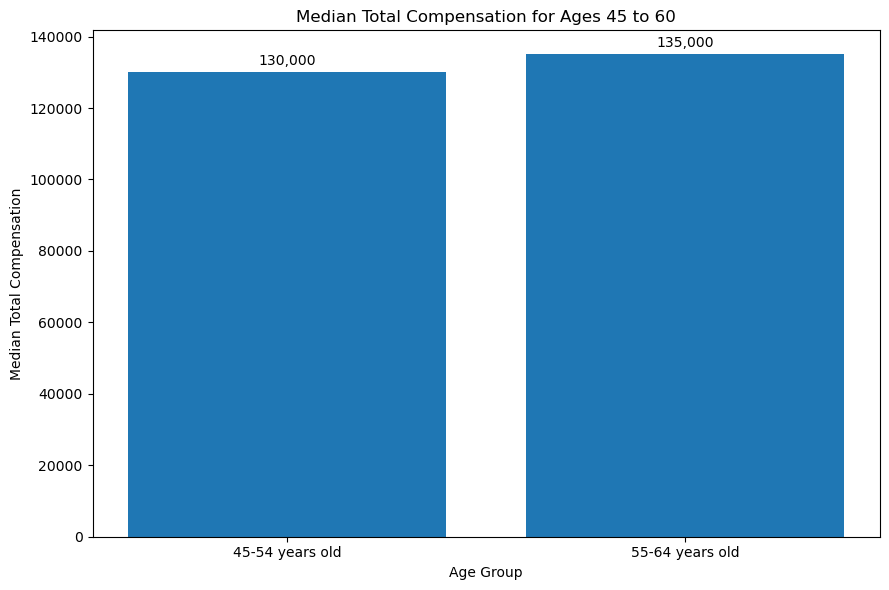

In [20]:
## Write your code here

QUERY = """
SELECT Age, CompTotal
FROM main
WHERE Age IN (
    '45-54 years old',
    '55-64 years old'
)
AND CompTotal IS NOT NULL
"""

age_comp_df = pd.read_sql_query(QUERY, conn)

median_comp = (
    age_comp_df
    .groupby("Age", as_index=False)["CompTotal"]
    .median()
)

age_order = [
    "45-54 years old",
    "55-64 years old"
]

median_comp["Age"] = pd.Categorical(
    median_comp["Age"],
    categories=age_order,
    ordered=True
)

median_comp = median_comp.sort_values("Age")

print(median_comp)

plt.figure(figsize=(9, 6))

bars = plt.bar(
    median_comp["Age"],
    median_comp["CompTotal"]
)

plt.title("Median Total Compensation for Ages 45 to 60")
plt.xlabel("Age Group")
plt.ylabel("Median Total Compensation")

plt.bar_label(
    bars,
    labels=[
        f"{value:,.0f}"
        for value in median_comp["CompTotal"]
    ],
    padding=3
)

plt.tight_layout()
plt.show()

**Bar Chart**

Create a horizontal bar chart using the `MainBranch` column.


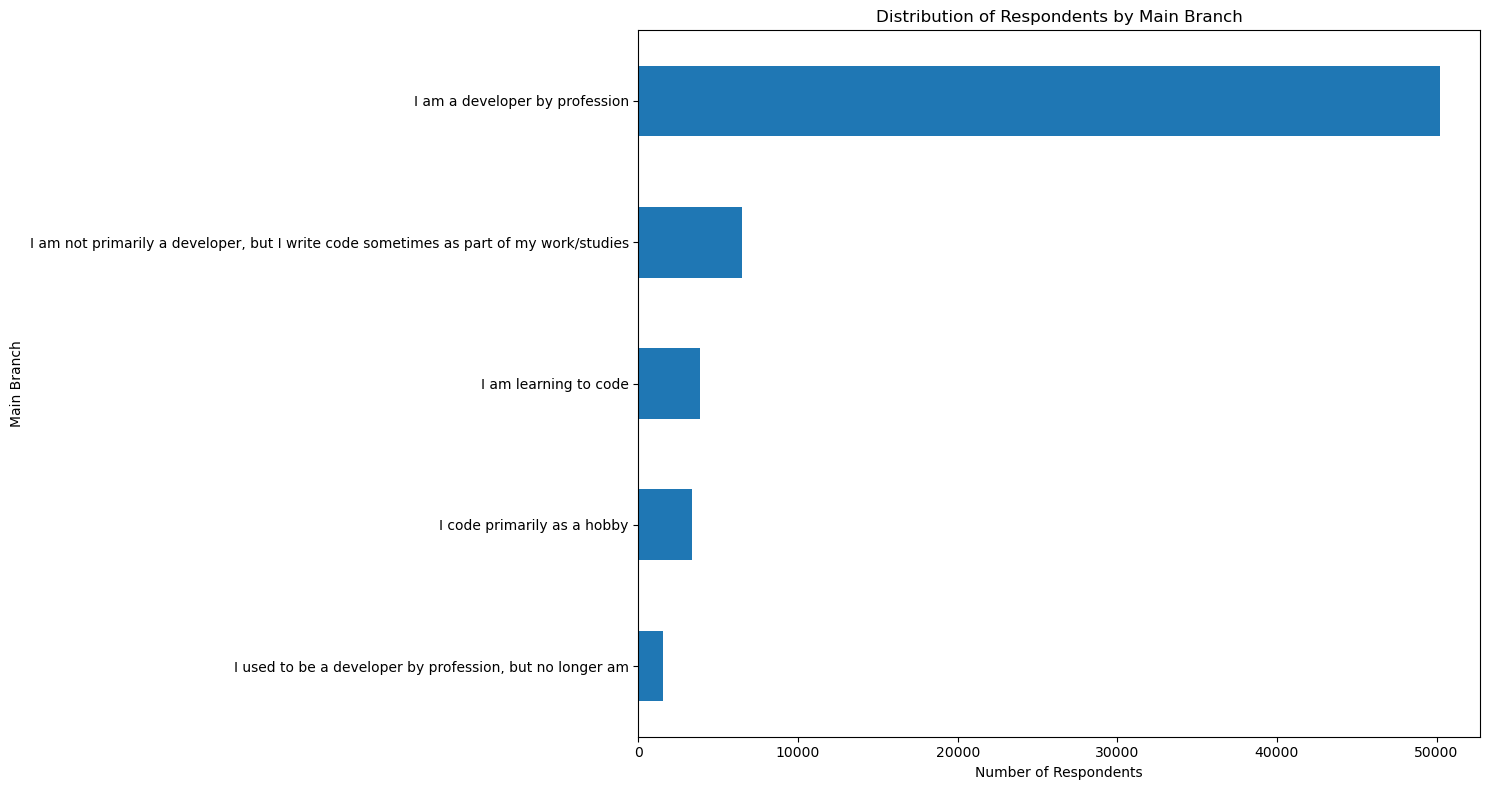

In [23]:
## Write your code here

QUERY = """
SELECT MainBranch
FROM main
"""

mainbranch_df = pd.read_sql_query(QUERY, conn)

mainbranch_counts = (
    mainbranch_df["MainBranch"]
    .value_counts()
    .sort_values()
)

plt.figure(figsize=(15, 8))

mainbranch_counts.plot(kind='barh')

plt.title("Distribution of Respondents by Main Branch")
plt.xlabel("Number of Respondents")
plt.ylabel("Main Branch")

#plt.bar_(bars,labels=[f"{value:,}" for value in mainbranch_counts.values],padding=3)

plt.tight_layout()
plt.show()

### Summary


In this lab, you focused on extracting and visualizing data from an RDBMS using SQL queries and SQLite. You applied various visualization techniques, including:

- Histograms to display the distribution of CompTotal.
- Box plots to show the spread of ages.
- Scatter plots and bubble plots to explore relationships between variables like Age, WorkExp, `TimeSearching` and `TimeAnswering`.
- Pie charts and stacked charts to visualize the composition of data.
- Line charts and bar charts to compare data across categories.


### Close the Database Connection

Once the lab is complete, ensure to close the database connection:


In [24]:
conn.close()

## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
